<a href="https://colab.research.google.com/github/LielUziahu/MDPI_S_Pistillata_Bet-Hedging/blob/main/alkelinity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Block 1: Environment Setup, Package Installation & Plot Styling
Installs required packages and sets global publication-grade typography and aesthetic formatting.

In [1]:
# Block 1: Environment Setup & Global Styling
!pip install -q PyCO2SYS pingouin openpyxl

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import PyCO2SYS as pyco2

# MDPI / Nature publication plot aesthetics
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.edgecolor": "black",
    "axes.linewidth": 1.1,
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "text.color": "black",
    "legend.frameon": False,
    "figure.dpi": 300,
    "savefig.dpi": 600
})

treatment_order = ["pH 8.2", "pH 7.8", "pH 7.6"]
treatment_colors = {
    "pH 8.2": "#2b83ba",  # Ambient / Blue
    "pH 7.8": "#fdae61",  # Moderate OA / Orange
    "pH 7.6": "#d7191c"   # Severe OA / Red
}

print("✅ Block 1 Complete: Environment initialized and plot styles set.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.6/110.6 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 8.0 MB/s eta 0:00:00
✅ Block 1 Complete: Environment initialized and plot styles set.


Block 2: Data Loading & Time-Proportional Dickson CRM Drift Correction
## New Section
Reads Alkalinity_test.xlsx, isolates Dickson CRM runs, and applies time-proportional drift correction:
$$\text{TA}_{\text{corr}} = \text{TA}_{\text{device}} - (\text{CRM}_{1,\text{meas}} - \text{CRM}_{\text{cert}}) - \left[ \frac{N}{K+1} \times ((\text{CRM}_{2,\text{meas}} - \text{CRM}_{\text{cert}}) - (\text{CRM}_{1,\text{meas}} - \text{CRM}_{\text{cert}})) \right]$$



In [23]:
# Block 2: Load Data & Apply Time-Proportional CRM Drift Correction
excel_file = "Alkalinity_test.xlsx"

# Load sheets
xls = pd.ExcelFile(excel_file)
df_combine = pd.read_excel(excel_file, sheet_name="COMBINE")
df_loadout = pd.read_excel(excel_file, sheet_name="loadout")

# Normalize column names
df_combine.columns = df_combine.columns.str.strip()
df_loadout.columns = df_loadout.columns.str.strip()

# Heuristic identification for TA column
alinity_col_name = None
for col_name in df_combine.columns:
    if pd.api.types.is_numeric_dtype(df_combine[col_name]):
        numeric_vals = df_combine[col_name].dropna()
        if not numeric_vals.empty and numeric_vals.min() > 1500 and numeric_vals.max() < 3500:
            alinity_col_name = col_name
            break

if alinity_col_name:
    df_combine = df_combine.rename(columns={alinity_col_name: "TA_Value"})
else:
    raise KeyError("Could not identify TA column.")

CRM_CERTIFIED = 2218.84

# Parse timestamps
df_combine["Time"] = pd.to_datetime(df_combine["Time"].astype(str).str.replace(r'\\(.*\\)', '', regex=True).str.strip(), errors="coerce")
df_combine = df_combine.sort_values("Time").reset_index(drop=True)
df_combine["Is_CRM"] = df_combine["RS01.NAME"].astype(str).str.lower().str.contains("control|crm")

# CRM Drift Correction
crm_indices = df_combine.index[df_combine["Is_CRM"]].tolist()
corrected_dfs = []
for run_idx in range(len(crm_indices) - 1):
    idx_start, idx_end = crm_indices[run_idx], crm_indices[run_idx + 1]
    sub = df_combine.iloc[idx_start : idx_end + 1].copy()
    crm1_meas, crm2_meas = sub.iloc[0]["TA_Value"], sub.iloc[-1]["TA_Value"]
    samples = sub.iloc[1:-1].copy()
    if not samples.empty:
        k = len(samples)
        n = np.arange(1, k + 1)
        samples["TA_corrected"] = samples["TA_Value"] - (crm1_meas - CRM_CERTIFIED) - (n / (k + 1)) * (crm2_meas - crm1_meas)
        corrected_dfs.append(samples)

df_samples = pd.concat(corrected_dfs, ignore_index=True)

# Treatment Merging (Tank-based only, ignoring Date mismatch)
treatment_cols = ["pH 8.2", "pH 7.6", "pH 7.8"]
loadout_mapping = df_loadout.iloc[:6].melt(value_vars=treatment_cols, var_name="Treatment", value_name="TankID_Base")
loadout_mapping = loadout_mapping.dropna().drop_duplicates(subset=['TankID_Base'])

df_samples["TankID_Base"] = df_samples["RS01.NAME"].astype(str).str.split('_').str[0]
df_samples = df_samples.merge(loadout_mapping, on="TankID_Base", how="left")

print(f"\u2705 Block 2 Complete: Corrected {len(df_samples)} vials with Tank-based treatment mapping.")
display(df_samples[["Time", "RS01.NAME", "TA_corrected", "Treatment"]].head())

✅ Block 2 Complete: Corrected 36 vials with Tank-based treatment mapping.


/tmp/ipykernel_1365/1861403168.py:30: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_combine["Time"] = pd.to_datetime(df_combine["Time"].astype(str).str.replace(r'\\(.*\\)', '', regex=True).str.strip(), errors="coerce")


,Time,RS01.NAME,TA_corrected,Treatment
0,2026-07-14 12:18:13-03:00,L1_1,2118.878158,pH 8.2
1,2026-07-14 12:29:35-03:00,L1_2,1965.815316,pH 8.2
2,2026-07-14 12:41:23-03:00,L2_1,2250.663474,pH 7.6
3,2026-07-14 12:53:05-03:00,L2_2,2266.912632,pH 7.6
4,2026-07-14 13:04:31-03:00,L3_1,2373.672789,pH 7.8


In [20]:
print("--- Inspecting 'loadout' sheet for temporal mapping ---")
display(df_loadout.head(15))

# Identify if there is a 'Date', 'Day', or time-based column in the loadout
date_cols = [col for col in df_loadout.columns if 'date' in str(col).lower() or 'day' in str(col).lower() or 'Unnamed' in str(col)]
print(f"Potential temporal columns: {date_cols}")

--- Inspecting 'loadout' sheet for temporal mapping ---


,Unnamed: 0,pH 8.2,pH 7.6,pH 7.8
0,2025-05-01 00:00:00,L1,L2,L3
1,2025-05-04 00:00:00,L4,L5,L6
2,2025-05-06 00:00:00,L7,L8,L9
3,2025-05-09 00:00:00,L10,L11,L12
4,2025-05-11 00:00:00,L13,L14,L15
5,2025-05-14 00:00:00,L16,L17,L18
6,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN
8,NaN,Salinity,Total CO2,Total Alkalinity
9,NaN,NaN,micromol/kg,micromol/kg


Potential temporal columns: ['Unnamed: 0']


## Block 3: Technical Duplicate QC Gate, Replicate Averaging & $1.5\times\text{IQR}$ Outlier Filtering

Checks the $\Delta \le 70\ \mu\text{mol/kg}$ duplicate tolerance threshold, averages duplicate vials per tank, and cleans extreme outliers

In [9]:
# Block 3: Replicate QC Gate (±70 µmol/kg) & 1.5xIQR Cleaning

# Extract Base Sample/Tank ID (stripping _1, _2 suffixes)
df_samples["TankID"] = df_samples["RS01.NAME"].astype(str).str.replace(r'_[12]$', '', regex=True)

# Separate duplicates to evaluate delta
rep1 = df_samples[df_samples["RS01.NAME"].str.endswith("_1")].set_index("TankID")["TA_corrected"]
rep2 = df_samples[df_samples["RS01.NAME"].str.endswith("_2")].set_index("TankID")["TA_corrected"]

qc_table = pd.DataFrame({"TA_Rep1": rep1, "TA_Rep2": rep2}).dropna()
qc_table["Delta"] = (qc_table["TA_Rep1"] - qc_table["TA_Rep2"]).abs()
qc_table["QC_Status"] = np.where(qc_table["Delta"] <= 70.0, "PASS", "FAIL (>70)")

print("=== Technical Duplicate QC Summary ===")
print(qc_table)

# Average replicates per TankID
df_averaged = df_samples.groupby("TankID").agg({
    "TA_corrected": "mean",
    "Treatment": "first"
}).reset_index().rename(columns={"TA_corrected": "TA"})

# Standardize Treatment labels to standard format (pH 8.2, pH 7.8, pH 7.6)
df_averaged["Treatment"] = df_averaged["Treatment"].astype(str).str.strip()
df_averaged["Treatment"] = df_averaged["Treatment"].replace({
    "8.2": "pH 8.2", "7.8": "pH 7.8", "7.6": "pH 7.6",
    "C": "pH 8.2", "Control": "pH 8.2",
    "M": "pH 7.8", "Mid": "pH 7.8",
    "H": "pH 7.6", "High": "pH 7.6"
})
df_averaged = df_averaged[df_averaged["Treatment"].isin(treatment_order)].copy()

# Group-wise 1.5 x IQR Outlier Removal
def filter_group_iqr(df_in, val_col, group_col):
    cleaned = []
    for grp, data in df_in.groupby(group_col):
        q25 = data[val_col].quantile(0.25)
        q75 = data[val_col].quantile(0.75)
        iqr = q75 - q25
        lower = q25 - 1.5 * iqr
        upper = q75 + 1.5 * iqr
        valid = data[(data[val_col] >= lower) & (data[val_col] <= upper)]
        cleaned.append(valid)
    return pd.concat(cleaned, ignore_index=True)

df_clean_ta = filter_group_iqr(df_averaged, "TA", "Treatment")
print(f"\n✅ Block 3 Complete: {len(df_clean_ta)} tank samples retained after QC & 1.5xIQR filtering.")

=== Technical Duplicate QC Summary ===
            TA_Rep1      TA_Rep2       Delta   QC_Status
TankID                                                  
L1      2118.878158  1965.815316  153.062842  FAIL (>70)
L2      2250.663474  2266.912632   16.249158        PASS
L3      2373.672789  2382.353947    8.681158        PASS
L4      2056.638105  2060.320263    3.682158        PASS
L5      2360.299421  2374.178579   13.879158        PASS
L6      2456.730737  2507.097895   50.367158        PASS
L7      2228.206053  2252.283211   24.077158        PASS
L8      2550.132368  2573.895526   23.763158        PASS
L9      2581.419684  2632.223842   50.804158        PASS
L10     2338.639211  2239.359421   99.279789  FAIL (>70)
L11     2537.289632  2522.751842   14.537789        PASS
L12     2486.610053  2504.207263   17.597211        PASS
L13     2122.739474  2059.601684   63.137789        PASS
L14     2603.999895  2586.144105   17.855789        PASS
L15     2461.432316  2470.760526    9.328211     

## Block 4: Full Carbonate Chemistry System Computation (PyCO2SYS)

Computes $\text{DIC}$, $p\text{CO}_2$, $\text{HCO}_3^-$, $\text{CO}_3^{2-}$, and $\Omega_{\text{Aragonite}}$ at $S=39.0$ and $T=23.0^\circ\text{C}$.


In [30]:
# Block 4: Solve Carbonate Chemistry System using PyCO2SYS
SALINITY, TEMPERATURE, PRESSURE = 39.0, 23.0, 0.0
treatment_ph_map = {"pH 8.2": 8.18, "pH 7.8": 7.79, "pH 7.6": 7.58}

df_clean_ta["pH_Total"] = df_clean_ta["Treatment"].map(treatment_ph_map)
df_clean_ta["Salinity"] = SALINITY
df_clean_ta["Temperature"] = TEMPERATURE

# Using standard parameter indices and modern keyword arguments for PyCO2SYS v1.8+
carb_results = pyco2.sys(
    par1=df_clean_ta["TA"].values,
    par2=df_clean_ta["pH_Total"].values,
    par1_type=1,
    par2_type=3,
    salinity=SALINITY,
    temperature=TEMPERATURE,
    pressure=PRESSURE,
    opt_pH_scale=1,    # Total scale
    opt_k_carbonic=10, # Lueker et al. 2000
    opt_k_fluoride=1,  # Perez & Fraga 1987
    opt_k_bisulfate=1  # Dickson 1990
)

df_carb = df_clean_ta.copy()
# Mapping results using the exact case-sensitive keys returned by the library
# Mapping results using PyCO2SYS case-sensitive keys
df_carb["DIC"] = carb_results["dic"]
df_carb["pCO2"] = carb_results["pCO2"]
df_carb["CO3"] = carb_results["CO3"]
df_carb["HCO3"] = carb_results["HCO3"]
df_carb["AragSat"] = carb_results["saturation_aragonite"]

print("\u2705 Block 4 Complete: Carbonate chemistry calculated.")
display(df_carb[["TankID", "Treatment", "TA", "DIC", "pCO2"]].head())

✅ Block 4 Complete: Carbonate chemistry calculated.


,TankID,Treatment,TA,DIC,pCO2
0,L11,pH 7.6,2530.020737,2434.861789,1473.243554
1,L14,pH 7.6,2595.072000,2498.533423,1511.768872
2,L17,pH 7.6,2502.046263,2407.480607,1456.676227
3,L2,pH 7.6,2258.788053,2169.381497,1312.611385
4,L5,pH 7.6,2367.239000,2275.532381,1376.839304


## Block 5: Automated Statistical Testing (Normality, Homogeneity & ANOVA/Kruskal-Wallis)

Tests Shapiro-Wilk normality and Levene's variance homogeneity before routing to One-Way ANOVA with Tukey HSD or Kruskal-Wallis non-parametric tests.


In [31]:
# Block 5: Automated Statistical Testing & Post-Hoc Analysis
parameters = ["TA", "pH_Total", "DIC", "pCO2", "HCO3", "CO3", "AragSat"]
stat_summary_records = []

print("="*75)
print(" STATISTICAL HYPOTHESIS TESTING SUMMARY (Treatment Effect: 8.2 vs 7.8 vs 7.6)")
print("="*75)

for param in parameters:
    # 1. Normality Check (Shapiro-Wilk)
    p_norm_vals = [stats.shapiro(group[param])[1] for _, group in df_carb.groupby("Treatment") if len(group) >= 3]
    is_normal = all(p > 0.05 for p in p_norm_vals) if p_norm_vals else True

    # 2. Homogeneity of Variance (Levene)
    groups = [group[param].values for _, group in df_carb.groupby("Treatment")]
    _, p_levene = stats.levene(*groups)
    is_homo = p_levene > 0.05

    # 3. Model Routing
    if is_normal and is_homo:
        # Standard Parametric One-Way ANOVA
        f_val, p_val = stats.f_oneway(*groups)
        test_used = "One-Way ANOVA"
        tukey = pairwise_tukeyhsd(endog=df_carb[param], groups=df_carb["Treatment"], alpha=0.05)
        posthoc_summary = "; ".join([f"{row[0]}-{row[1]}: p={row[3]:.4f}" for row in tukey.summary().data[1:]])
    else:
        # Non-Parametric Kruskal-Wallis Test
        h_val, p_val = stats.kruskal(*groups)
        test_used = "Kruskal-Wallis"
        posthoc_summary = "Non-parametric rank test applied"

    stat_summary_records.append({
        "Parameter": param,
        "Normality (p>0.05)": is_normal,
        "Homoscedastic (p>0.05)": is_homo,
        "Test": test_used,
        "P-value": p_val,
        "Post-Hoc Contrasts": posthoc_summary
    })

df_stats_report = pd.DataFrame(stat_summary_records)
print(df_stats_report[["Parameter", "Test", "P-value", "Post-Hoc Contrasts"]].to_string(index=False))

 STATISTICAL HYPOTHESIS TESTING SUMMARY (Treatment Effect: 8.2 vs 7.8 vs 7.6)


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_morestats.py:3104: RuntimeWarning: invalid value encountered in scalar divide
  W = numer / denom


Parameter           Test      P-value                                                        Post-Hoc Contrasts
       TA  One-Way ANOVA 9.412775e-05 pH 7.6-pH 7.8: p=0.9694; pH 7.6-pH 8.2: p=0.0002; pH 7.8-pH 8.2: p=0.0004
 pH_Total Kruskal-Wallis 5.530844e-04                                          Non-parametric rank test applied
      DIC  One-Way ANOVA 1.123062e-07 pH 7.6-pH 7.8: p=0.4730; pH 7.6-pH 8.2: p=0.0000; pH 7.8-pH 8.2: p=0.0000
     pCO2  One-Way ANOVA 9.988534e-15 pH 7.6-pH 7.8: p=0.0000; pH 7.6-pH 8.2: p=0.0000; pH 7.8-pH 8.2: p=0.0000
     HCO3  One-Way ANOVA 4.789293e-09 pH 7.6-pH 7.8: p=0.1784; pH 7.6-pH 8.2: p=0.0000; pH 7.8-pH 8.2: p=0.0000
      CO3  One-Way ANOVA 4.607195e-13 pH 7.6-pH 7.8: p=0.0000; pH 7.6-pH 8.2: p=0.0000; pH 7.8-pH 8.2: p=0.0000
  AragSat  One-Way ANOVA 4.607195e-13 pH 7.6-pH 7.8: p=0.0000; pH 7.6-pH 8.2: p=0.0000; pH 7.8-pH 8.2: p=0.0000


## Block 6: Multi-Panel Publication-Ready Vector Figure (600 DPI)

Renders a 6-panel composite graphic featuring boxplots, sample points, mean diamonds, and significance styling.  


/tmp/ipykernel_1365/2282591024.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1365/2282591024.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1365/2282591024.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1365/2282591024.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1365/2282591024.py:19: FutureWarning: 

P

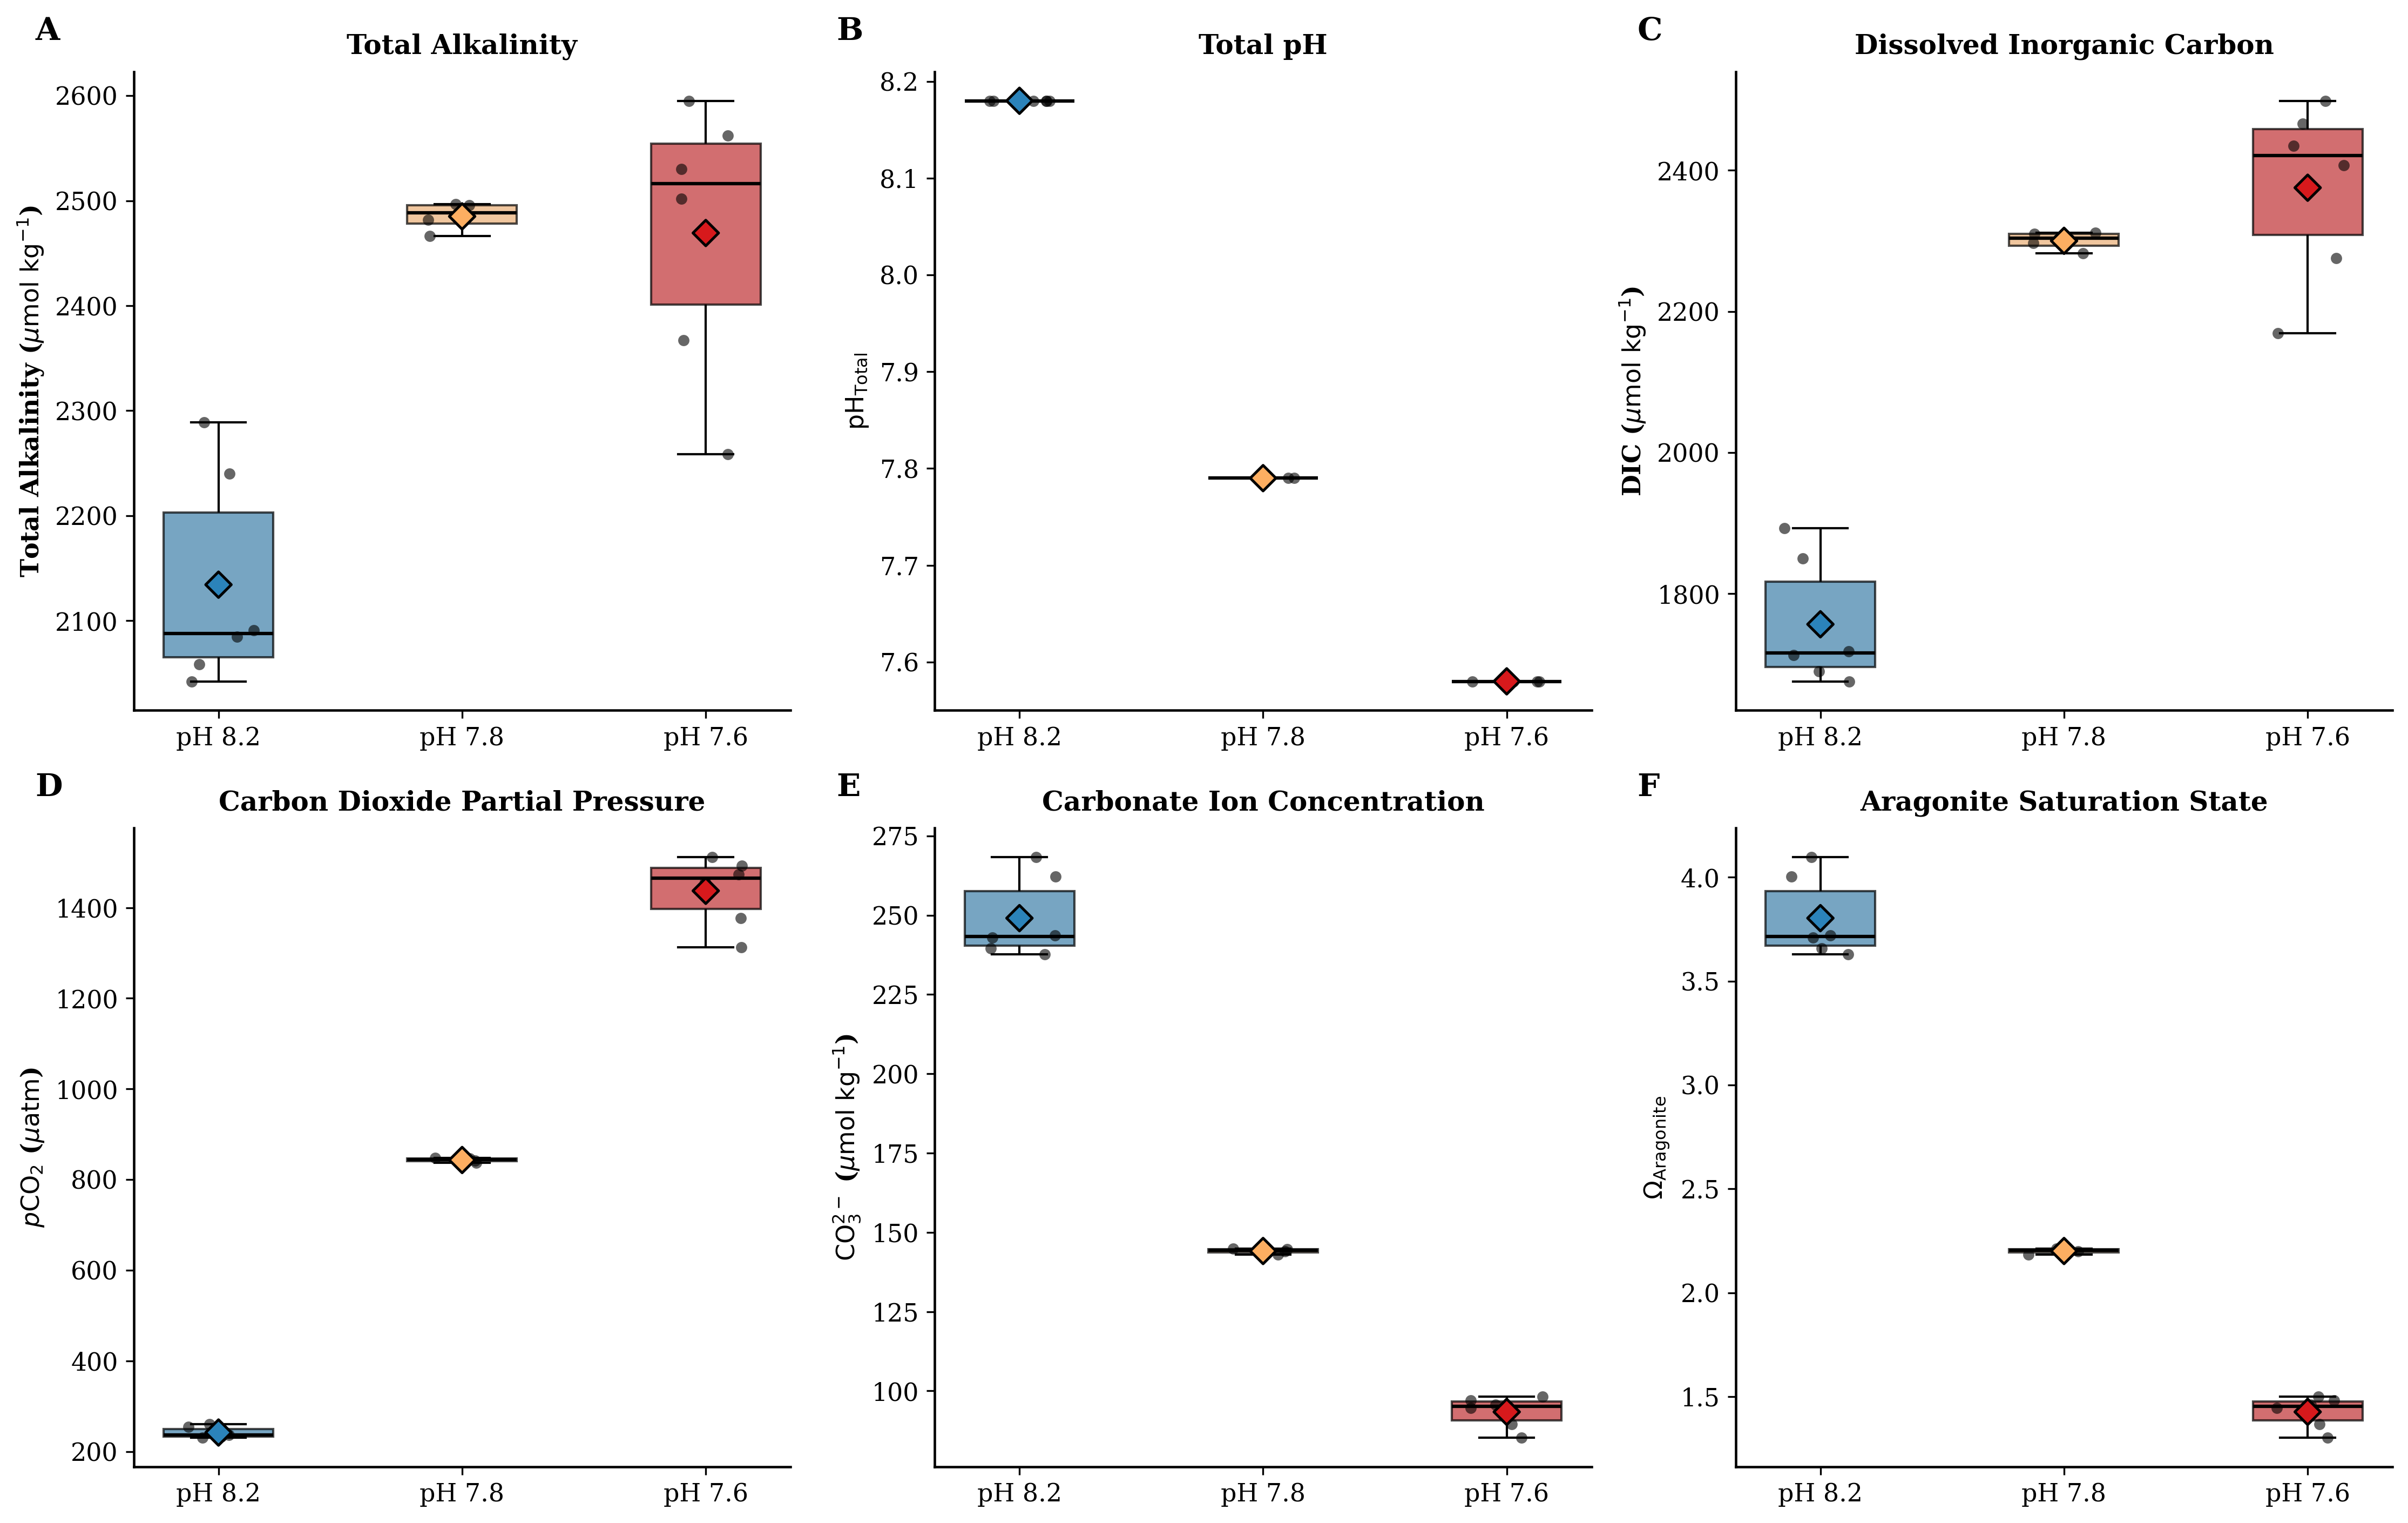

✅ Block 6 Complete: Saved 'CarbChem_Master_Panel.png' (600 DPI) and vector PDF.


In [32]:
# Block 6: Multi-Panel Publication Graphics Generation
panel_configs = [
    {"col": "TA", "ylabel": r"Total Alkalinity ($\mu\mathrm{mol\ kg^{-1}}$)", "title": "Total Alkalinity", "tag": "A"},
    {"col": "pH_Total", "ylabel": r"$\mathrm{pH_{Total}}$", "title": "Total pH", "tag": "B"},
    {"col": "DIC", "ylabel": r"DIC ($\mu\mathrm{mol\ kg^{-1}}$)", "title": "Dissolved Inorganic Carbon", "tag": "C"},
    {"col": "pCO2", "ylabel": r"$p\mathrm{CO_2}$ ($\mu\mathrm{atm}$)", "title": "Carbon Dioxide Partial Pressure", "tag": "D"},
    {"col": "CO3", "ylabel": r"$\mathrm{CO_3^{2-}}$ ($\mu\mathrm{mol\ kg^{-1}}$)", "title": "Carbonate Ion Concentration", "tag": "E"},
    {"col": "AragSat", "ylabel": r"$\Omega_{\mathrm{Aragonite}}$", "title": "Aragonite Saturation State", "tag": "F"}
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9.5))
axes_flat = axes.flatten()

for i, conf in enumerate(panel_configs):
    ax = axes_flat[i]
    col = conf["col"]

    # Boxplot
    sns.boxplot(
        data=df_carb, x="Treatment", y=col, order=treatment_order,
        palette=treatment_colors, width=0.45, showfliers=False,
        boxprops=dict(edgecolor="black", alpha=0.7),
        whiskerprops=dict(color="black"), capprops=dict(color="black"),
        medianprops=dict(color="black", linewidth=1.5), ax=ax
    )

    # Strip plot (jittered raw tank samples)
    sns.stripplot(
        data=df_carb, x="Treatment", y=col, order=treatment_order,
        color="black", size=5, jitter=0.15, alpha=0.6, ax=ax
    )

    # Mean Diamond
    means = df_carb.groupby("Treatment")[col].mean().reindex(treatment_order)
    ax.scatter(
        range(len(treatment_order)), means,
        color=[treatment_colors[t] for t in treatment_order],
        marker="D", s=65, edgecolors="black", linewidths=1.2, zorder=5
    )

    # Subpanel tags (A-F)
    ax.text(-0.15, 1.05, conf["tag"], transform=ax.transAxes, fontsize=14, fontweight="bold")

    ax.set_title(conf["title"], fontsize=12, fontweight="bold", pad=8)
    ax.set_ylabel(conf["ylabel"], fontsize=11, fontweight="bold")
    ax.set_xlabel("")
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig("CarbChem_Master_Panel.png", dpi=600, bbox_inches="tight")
plt.savefig("CarbChem_Master_Panel.pdf", bbox_inches="tight")
plt.show()

print("✅ Block 6 Complete: Saved 'CarbChem_Master_Panel.png' (600 DPI) and vector PDF.")

## Block 7: Manuscript Summary Table (Mean $\pm$ SE Export)

Calculates formatted descriptive statistics with Unicode symbols ready for manuscript submission.  

In [33]:
# Block 7: Formatted Manuscript Summary Table
summary_df = df_carb.groupby("Treatment").agg({
    "Salinity": ["mean", lambda x: stats.sem(x, nan_policy="omit")],
    "Temperature": ["mean", lambda x: stats.sem(x, nan_policy="omit")],
    "pH_Total": ["mean", lambda x: stats.sem(x, nan_policy="omit")],
    "TA": ["mean", lambda x: stats.sem(x, nan_policy="omit")],
    "DIC": ["mean", lambda x: stats.sem(x, nan_policy="omit")],
    "pCO2": ["mean", lambda x: stats.sem(x, nan_policy="omit")],
    "HCO3": ["mean", lambda x: stats.sem(x, nan_policy="omit")],
    "CO3": ["mean", lambda x: stats.sem(x, nan_policy="omit")],
    "AragSat": ["mean", lambda x: stats.sem(x, nan_policy="omit")]
}).reindex(treatment_order)

# Flatten columns & format as Mean ± SE
formatted_table = pd.DataFrame(index=treatment_order)
param_labels = {
    "Salinity": "Salinity (psu)",
    "Temperature": "Temperature (°C)",
    "pH_Total": "Total pH",
    "TA": "Total Alkalinity (µmol kg⁻¹)",
    "DIC": "DIC (µmol kg⁻¹)",
    "pCO2": "pCO₂ (µatm)",
    "HCO3": "HCO₃⁻ (µmol kg⁻¹)",
    "CO3": "CO₃²⁻ (µmol kg⁻¹)",
    "AragSat": "Ω_Aragonite"
}

for p_key, p_name in param_labels.items():
    m = summary_df[(p_key, "mean")].round(2)
    se = summary_df[(p_key, "<lambda_0>")].round(2)
    formatted_table[p_name] = [f"{mean_v:.2f} ± {se_v:.2f}" for mean_v, se_v in zip(m, se)]

formatted_table = formatted_table.reset_index().rename(columns={"index": "Treatment"})
formatted_table.to_csv("CarbChem_Manuscript_Summary_Table.csv", index=False)

print("=== Final Manuscript Carbonate Chemistry Table ===")
display(formatted_table)

=== Final Manuscript Carbonate Chemistry Table ===


,Treatment,Salinity (psu),Temperature (°C),Total pH,Total Alkalinity (µmol kg⁻¹),DIC (µmol kg⁻¹),pCO₂ (µatm),HCO₃⁻ (µmol kg⁻¹),CO₃²⁻ (µmol kg⁻¹),Ω_Aragonite
0,pH 8.2,39.00 ± 0.00,23.00 ± 0.00,8.18 ± 0.00,2134.37 ± 42.29,1756.64 ± 37.17,241.83 ± 5.12,1500.52 ± 31.75,249.06 ± 5.27,3.80 ± 0.08
1,pH 7.8,39.00 ± 0.00,23.00 ± 0.00,7.79 ± 0.00,2485.03 ± 7.14,2300.08 ± 6.79,843.20 ± 2.49,2131.37 ± 6.29,144.12 ± 0.43,2.20 ± 0.01
2,pH 7.6,39.00 ± 0.00,23.00 ± 0.00,7.58 ± 0.00,2469.20 ± 52.89,2375.33 ± 51.76,1437.22 ± 31.32,2240.01 ± 48.81,93.39 ± 2.04,1.43 ± 0.03


## Block 8: Temporal Trend Analysis
This block maps the experimental dates from the 'loadout' sheet to the calculated carbonate chemistry data to visualize trends over time.

<Figure size 3600x1800 with 0 Axes>

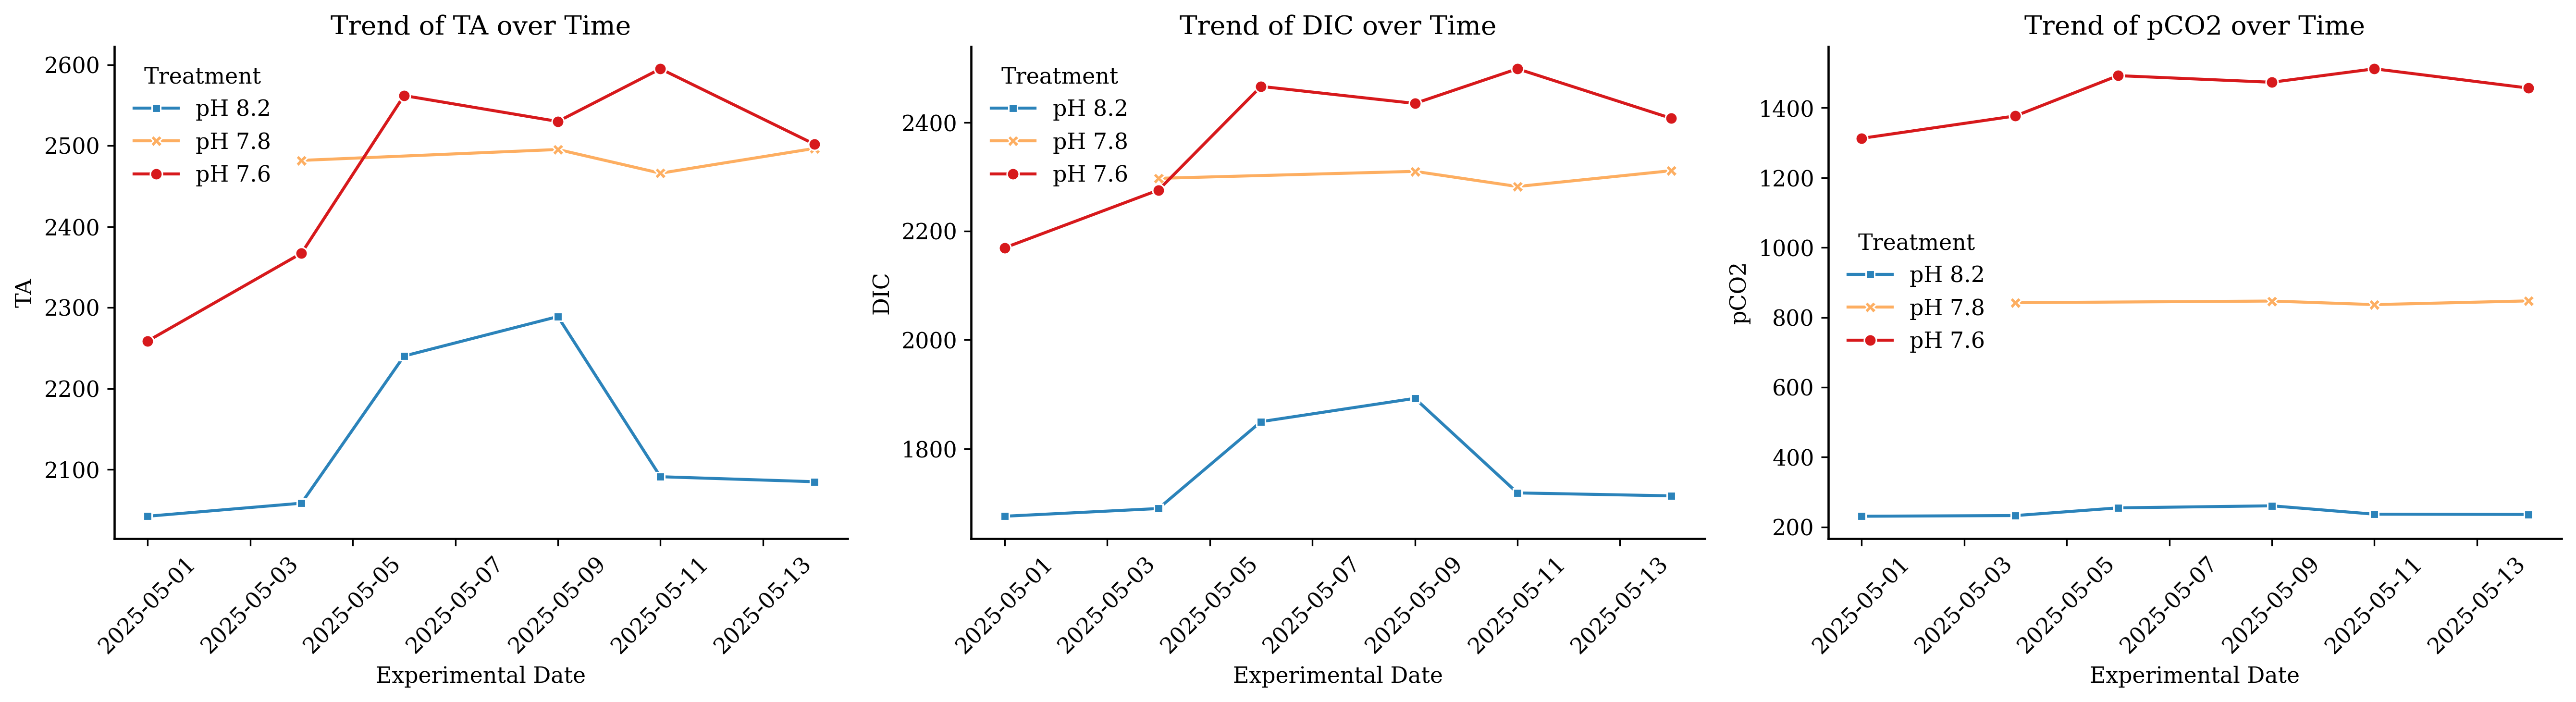

✅ Block 8 Complete: Temporal trends generated.


In [34]:
# Block 8: Temporal Trend Mapping and Visualization

# 1. Extract Date-to-Tank mapping from loadout sheet
# We'll use the 'Unnamed: 0' column which was identified as the date column
df_dates = df_loadout.iloc[:6][['Unnamed: 0', 'pH 8.2', 'pH 7.6', 'pH 7.8']].copy()
df_dates = df_dates.rename(columns={'Unnamed: 0': 'ExpDate'})

# Melt to get a long format of Date -> TankID
date_map = df_dates.melt(id_vars='ExpDate', value_vars=['pH 8.2', 'pH 7.6', 'pH 7.8'],
                         var_name='Treatment_Check', value_name='TankID')
date_map = date_map.dropna(subset=['TankID'])
date_map['ExpDate'] = pd.to_datetime(date_map['ExpDate']).dt.date

# 2. Merge dates into our final dataset
df_trends = df_carb.merge(date_map[['ExpDate', 'TankID']], on='TankID', how='left')

# 3. Plotting the trends
plt.figure(figsize=(12, 6))
params_to_plot = ['TA', 'DIC', 'pCO2']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, param in enumerate(params_to_plot):
    sns.lineplot(data=df_trends, x='ExpDate', y=param, hue='Treatment',
                 style='Treatment', markers=True, dashes=False,
                 palette=treatment_colors, hue_order=treatment_order, ax=axes[i])

    axes[i].set_title(f'Trend of {param} over Time')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_xlabel('Experimental Date')
    sns.despine(ax=axes[i])

plt.tight_layout()
plt.show()

print("✅ Block 8 Complete: Temporal trends generated.")